<a href="https://colab.research.google.com/github/Sayesha81/FireSense-Free-Fire-MAX-ML-Dashboard/blob/main/Free_Fire_MAX_Player_Review_Intelligence_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle gradio

In [2]:
# ==============================
# CELL 2: Setup Kaggle API & Download Dataset
# ==============================

# Upload your kaggle.json file (get it from kaggle.com -> Account -> Create New API Token)
from google.colab import files
print("Please upload your kaggle.json file")
uploaded = files.upload()

# Configure Kaggle API credentials
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download the Free Fire MAX reviews dataset
!kaggle datasets download -d bagush/free-fire-max-mobile-game-reviews-google-play -p /content/data --unzip

Please upload your kaggle.json file


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/bagush/free-fire-max-mobile-game-reviews-google-play
License(s): MIT
100% 27.5M/27.5M [00:00<00:00, 96.5MB/s]



In [3]:
# ==============================
# CELL 3: Load Dataset
# ==============================

import pandas as pd

# Locate the CSV file inside the downloaded folder
import glob
csv_path = glob.glob('/content/data/*.csv')[0]
print("Found file:", csv_path)

# Load dataset into a DataFrame
df = pd.read_csv(csv_path)

# Quick look at the data
print("Shape:", df.shape)
df.head()

Found file: /content/data/Free Fire MAX.csv
Shape: (522970, 5)


,reviewId,userName,content,score,at
0,3dd466d0-8de5-48b6-bbeb-827464e52cea,Laxman Singh,old pic,1,2025-06-22 23:59:42
1,ce1493c5-08b3-46d0-abaf-7fbb32a00672,Yash Ff,good game but paid to win,2,2025-06-22 23:59:11
2,759fe181-a70a-4e8a-96cb-e8a23ef6ddf8,Shankar Reena,very good game,5,2025-06-22 23:59:11
3,325686e5-0db4-4547-9e9b-adeb8913115f,Devi A,Super,5,2025-06-22 23:58:23
4,2ed4cd5a-45a0-4ad4-87d5-d87b7a550422,You A,Ff day by day cartoon made and glitches or pro...,1,2025-06-22 23:58:13


In [4]:
# ==============================
# CELL 4: Dataset Inspection
# ==============================

# Column names and data types
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# General info
print("\nInfo:")
df.info()

# Basic statistics for numeric column(s)
print("\nScore statistics:\n", df['score'].describe())

Columns: ['reviewId', 'userName', 'content', 'score', 'at']

Data types:
 reviewId    object
userName    object
content     object
score        int64
at          object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522970 entries, 0 to 522969
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  522970 non-null  object
 1   userName  522970 non-null  object
 2   content   522967 non-null  object
 3   score     522970 non-null  int64 
 4   at        522970 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.9+ MB

Score statistics:
 count    522970.000000
mean          3.752745
std           1.772614
min           1.000000
25%           1.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: score, dtype: float64


In [5]:
# ==============================
# CELL 5: Missing Values & Duplicates Check
# ==============================

# Check missing values per column
print("Missing values per column:\n", df.isnull().sum())

# Check duplicate rows
print("\nTotal duplicate rows:", df.duplicated().sum())

# Check duplicate reviewIds specifically
print("Duplicate reviewId count:", df['reviewId'].duplicated().sum())

# Check for empty/whitespace-only content
empty_content = df['content'].isnull() | (df['content'].astype(str).str.strip() == '')
print("Empty/blank content rows:", empty_content.sum())

Missing values per column:
 reviewId    0
userName    0
content     3
score       0
at          0
dtype: int64

Total duplicate rows: 0
Duplicate reviewId count: 0
Empty/blank content rows: 3


In [6]:
# ==============================
# CELL 6: Data Cleaning
# ==============================

print("Before cleaning:", df.shape)

# Drop rows with missing or blank content
df = df.dropna(subset=['content'])
df = df[df['content'].astype(str).str.strip() != '']

# Drop duplicate rows based on reviewId (keep first occurrence)
df = df.drop_duplicates(subset=['reviewId'], keep='first')

# Drop duplicate content (exact same review text)
df = df.drop_duplicates(subset=['content'], keep='first')

# Ensure score is numeric and within valid range (1-5)
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df = df.dropna(subset=['score'])
df = df[df['score'].between(1, 5)]
df['score'] = df['score'].astype(int)

# Parse 'at' column as datetime
df['at'] = pd.to_datetime(df['at'], errors='coerce')
df = df.dropna(subset=['at'])

# Reset index after cleaning
df = df.reset_index(drop=True)

print("After cleaning:", df.shape)
df.head()

Before cleaning: (522970, 5)
After cleaning: (345764, 5)


,reviewId,userName,content,score,at
0,3dd466d0-8de5-48b6-bbeb-827464e52cea,Laxman Singh,old pic,1,2025-06-22 23:59:42
1,ce1493c5-08b3-46d0-abaf-7fbb32a00672,Yash Ff,good game but paid to win,2,2025-06-22 23:59:11
2,759fe181-a70a-4e8a-96cb-e8a23ef6ddf8,Shankar Reena,very good game,5,2025-06-22 23:59:11
3,325686e5-0db4-4547-9e9b-adeb8913115f,Devi A,Super,5,2025-06-22 23:58:23
4,2ed4cd5a-45a0-4ad4-87d5-d87b7a550422,You A,Ff day by day cartoon made and glitches or pro...,1,2025-06-22 23:58:13


In [7]:
# ==============================
# CELL 7: Add Sentiment Labels
# ==============================

def map_sentiment(score):
    # 1-2 = Negative, 3 = Neutral, 4-5 = Positive
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

# Vectorized mapping using pandas (fast, no loops)
df['sentiment'] = df['score'].map({1:'Negative', 2:'Negative', 3:'Neutral', 4:'Positive', 5:'Positive'})

# Add review length column (word count) - vectorized
df['review_length'] = df['content'].astype(str).str.split().str.len()

print(df[['score', 'sentiment', 'review_length']].head())
print("\nSentiment counts:\n", df['sentiment'].value_counts())

   score sentiment  review_length
0      1  Negative              2
1      2  Negative              6
2      5  Positive              3
3      5  Positive              1
4      1  Negative             10

Sentiment counts:
 sentiment
Positive    225286
Negative    110742
Neutral       9736
Name: count, dtype: int64


Rating distribution:
 score
1    101289
2      9453
3      9736
4     15696
5    209590
Name: count, dtype: int64


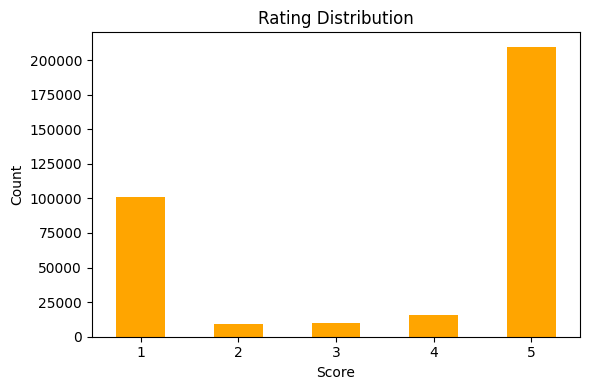

In [8]:
# ==============================
# CELL 8: EDA - Rating Distribution
# ==============================

import matplotlib.pyplot as plt

# Count of each rating (1-5) - vectorized value_counts on full dataset (cheap)
rating_counts = df['score'].value_counts().sort_index()
print("Rating distribution:\n", rating_counts)

# Plot rating distribution
plt.figure(figsize=(6,4))
rating_counts.plot(kind='bar', color='orange')
plt.title('Rating Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Sentiment distribution:
 sentiment
Positive    225286
Negative    110742
Neutral       9736
Name: count, dtype: int64


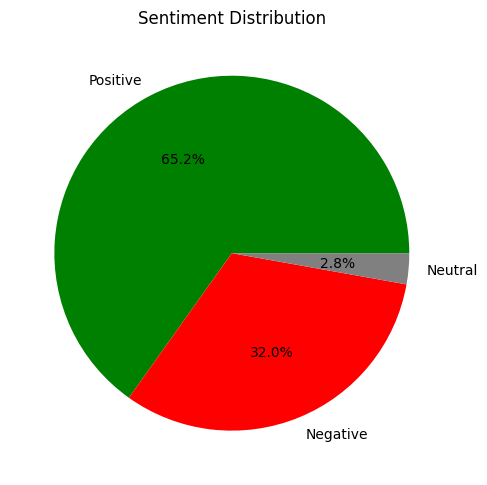

In [9]:
# ==============================
# CELL 9: EDA - Sentiment Distribution
# ==============================

# Sentiment counts (cheap, already computed column) - vectorized
sentiment_counts = df['sentiment'].value_counts()
print("Sentiment distribution:\n", sentiment_counts)

# Plot sentiment distribution as pie chart
plt.figure(figsize=(5,5))
colors = {'Positive':'green', 'Neutral':'gray', 'Negative':'red'}
plt.pie(sentiment_counts.values, labels=sentiment_counts.index,
        autopct='%1.1f%%', colors=[colors[s] for s in sentiment_counts.index])
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.show()

Review length statistics:
 count    345764.000000
mean         10.442776
std          13.067907
min           1.000000
25%           4.000000
50%           6.000000
75%          11.000000
max         147.000000
Name: review_length, dtype: float64


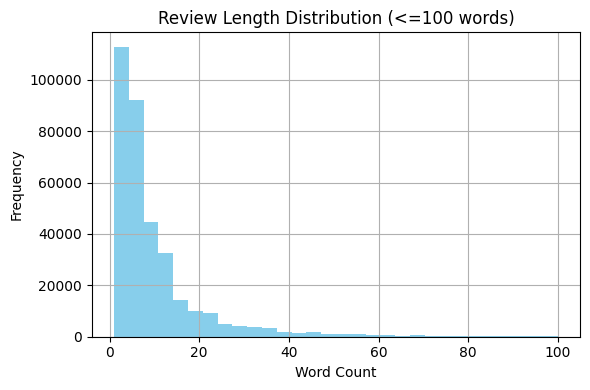


Average review length by sentiment:
 sentiment
Negative    12.551670
Neutral     14.400370
Positive     9.235092
Name: review_length, dtype: float64


In [10]:
# ==============================
# CELL 10: EDA - Review Length Analysis
# ==============================

# Review length statistics (already computed column, cheap)
print("Review length statistics:\n", df['review_length'].describe())

# Plot review length distribution (capped at 100 words for readability)
plt.figure(figsize=(6,4))
df[df['review_length'] <= 100]['review_length'].hist(bins=30, color='skyblue')
plt.title('Review Length Distribution (<=100 words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Average review length by sentiment - vectorized groupby
print("\nAverage review length by sentiment:\n", df.groupby('sentiment')['review_length'].mean())

Monthly review counts (first 10):
 year_month
2024-12    10648
2025-01    54773
2025-02    88072
2025-03    53430
2025-04    39418
2025-05    68088
2025-06    31335
Freq: M, dtype: int64


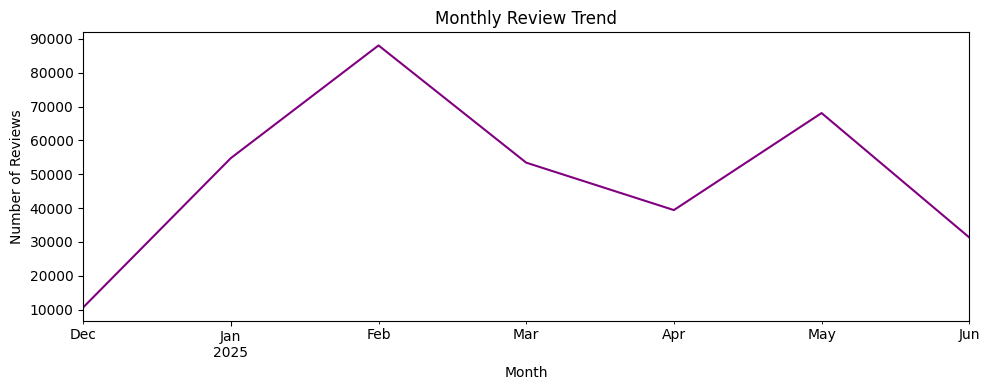

In [11]:
# ==============================
# CELL 11: EDA - Monthly Review Trend
# ==============================

# Extract year-month from 'at' column - vectorized
df['year_month'] = df['at'].dt.to_period('M')

# Count reviews per month - vectorized groupby (cheap on full dataset)
monthly_trend = df.groupby('year_month').size()

print("Monthly review counts (first 10):\n", monthly_trend.head(10))

# Plot monthly trend
plt.figure(figsize=(10,4))
monthly_trend.plot(kind='line', color='purple')
plt.title('Monthly Review Trend')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [12]:
# ==============================
# CELL 12: Create Balanced ML Dataset (25k/25k/25k)
# ==============================

# Sample up to 25,000 rows per sentiment class using random_state=42
n_per_class = 25000

balanced_parts = []
for sentiment_label in ['Negative', 'Neutral', 'Positive']:
    subset = df[df['sentiment'] == sentiment_label]
    sample_size = min(n_per_class, len(subset))
    sampled = subset.sample(n=sample_size, random_state=42)
    balanced_parts.append(sampled)
    print(f"{sentiment_label}: available={len(subset)}, sampled={sample_size}")

# Combine into one balanced dataframe
balanced_df = pd.concat(balanced_parts, axis=0)

# Shuffle the combined dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced dataset shape:", balanced_df.shape)
print(balanced_df['sentiment'].value_counts())

Negative: available=110742, sampled=25000
Neutral: available=9736, sampled=9736
Positive: available=225286, sampled=25000

Balanced dataset shape: (59736, 8)
sentiment
Negative    25000
Positive    25000
Neutral      9736
Name: count, dtype: int64


In [13]:
# ==============================
# CELL 13: Text Cleaning (on Balanced Dataset only)
# ==============================

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)             # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra whitespace
    return text

# Apply cleaning only on the 75k balanced dataset (fast, vectorized apply)
balanced_df['clean_content'] = balanced_df['content'].apply(clean_text)

# Remove rows that became empty after cleaning
balanced_df = balanced_df[balanced_df['clean_content'].str.strip() != ''].reset_index(drop=True)

print("Balanced dataset shape after cleaning:", balanced_df.shape)
balanced_df[['content', 'clean_content', 'sentiment']].head()


Balanced dataset shape after cleaning: (58035, 9)


,content,clean_content,sentiment
0,No thanks very good,no thanks very good,Neutral
1,50 Daimond,daimond,Negative
2,my 2 id was suspended for no reason,my id was suspended for no reason,Negative
3,Free fire not working game start not possible ...,free fire not working game start not possible ...,Positive
4,Free fire India jal vibhag wapas karo hamen kr...,free fire india jal vibhag wapas karo hamen kr...,Negative


In [14]:
# ==============================
# CELL 14: Train/Test Split
# ==============================

from sklearn.model_selection import train_test_split

X = balanced_df['clean_content']
y = balanced_df['sentiment']

# Stratified split to preserve class balance, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train shape: (46428,)
Test shape: (11607,)

Train class distribution:
 sentiment
Negative    19490
Positive    19315
Neutral      7623
Name: count, dtype: int64

Test class distribution:
 sentiment
Negative    4873
Positive    4828
Neutral     1906
Name: count, dtype: int64


In [15]:
# ==============================
# CELL 15: TF-IDF Vectorization
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer

# Optimized TF-IDF settings for Colab performance
tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

# Fit only on training data, transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)


TF-IDF train shape: (46428, 12000)
TF-IDF test shape: (11607, 12000)


In [16]:
# ==============================
# CELL 16: Train Logistic Regression Model
# ==============================

from sklearn.linear_model import LogisticRegression
import time

start_time = time.time()

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_tfidf, y_train)

print(f"Logistic Regression trained in {time.time() - start_time:.2f} seconds")

Logistic Regression trained in 6.33 seconds


In [17]:
# ==============================
# CELL 17: Train LinearSVC Model
# ==============================

from sklearn.svm import LinearSVC
import time

start_time = time.time()

linear_svc = LinearSVC(random_state=42, max_iter=2000)
linear_svc.fit(X_train_tfidf, y_train)

print(f"LinearSVC trained in {time.time() - start_time:.2f} seconds")

LinearSVC trained in 5.79 seconds


In [18]:
# ==============================
# CELL 18: Compare Accuracy & Weighted F1
# ==============================

from sklearn.metrics import accuracy_score, f1_score

# Predictions from both models
log_reg_preds = log_reg.predict(X_test_tfidf)
svc_preds = linear_svc.predict(X_test_tfidf)

# Compute metrics
log_reg_acc = accuracy_score(y_test, log_reg_preds)
log_reg_f1 = f1_score(y_test, log_reg_preds, average='weighted')

svc_acc = accuracy_score(y_test, svc_preds)
svc_f1 = f1_score(y_test, svc_preds, average='weighted')

# Store results in a comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'LinearSVC'],
    'Accuracy': [log_reg_acc, svc_acc],
    'Weighted F1': [log_reg_f1, svc_f1]
})

print(model_comparison)


                 Model  Accuracy  Weighted F1
0  Logistic Regression  0.682002     0.655828
1            LinearSVC  0.664082     0.645088


In [19]:
# ==============================
# CELL 19: Select Best Model
# ==============================

# Pick the model with the highest weighted F1 score
if svc_f1 >= log_reg_f1:
    best_model = linear_svc
    best_model_name = 'LinearSVC'
    best_preds = svc_preds
    best_acc = svc_acc
    best_f1 = svc_f1
else:
    best_model = log_reg
    best_model_name = 'Logistic Regression'
    best_preds = log_reg_preds
    best_acc = log_reg_acc
    best_f1 = log_reg_f1

print(f"Best Model Selected: {best_model_name}")
print(f"Accuracy: {best_acc:.4f}")
print(f"Weighted F1: {best_f1:.4f}")

Best Model Selected: Logistic Regression
Accuracy: 0.6820
Weighted F1: 0.6558


In [20]:
# ==============================
# CELL 20: Classification Report (Best Model)
# ==============================

from sklearn.metrics import classification_report

report_text = classification_report(y_test, best_preds)
print(f"Classification Report - {best_model_name}\n")
print(report_text)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

    Negative       0.68      0.80      0.74      4873
     Neutral       0.44      0.16      0.23      1906
    Positive       0.71      0.77      0.74      4828

    accuracy                           0.68     11607
   macro avg       0.61      0.58      0.57     11607
weighted avg       0.66      0.68      0.66     11607



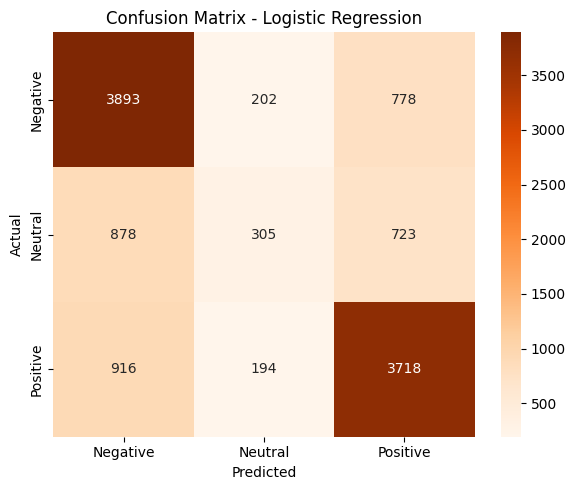

In [21]:
# ==============================
# CELL 21: Confusion Matrix (Best Model)
# ==============================

from sklearn.metrics import confusion_matrix
import seaborn as sns

labels_order = ['Negative', 'Neutral', 'Positive']
cm = confusion_matrix(y_test, best_preds, labels=labels_order)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [22]:
# ==============================
# CELL 22: Manual Sentiment Prediction Function
# ==============================

def predict_sentiment(text):
    # Clean the input text using the same cleaning function
    cleaned = clean_text(text)

    # Transform using the fitted TF-IDF vectorizer
    vec = tfidf.transform([cleaned])

    # Predict using the best model
    prediction = best_model.predict(vec)[0]

    # Get confidence score if the model supports probabilities
    confidence = None
    if hasattr(best_model, 'predict_proba'):
        proba = best_model.predict_proba(vec)[0]
        confidence = max(proba)
    elif hasattr(best_model, 'decision_function'):
        # For LinearSVC, use decision_function margin as a pseudo-confidence
        scores = best_model.decision_function(vec)[0]
        confidence = float(max(scores) - min(scores))  # relative margin

    return prediction, confidence

# Test the function with sample reviews
test_reviews = [
    "This game is amazing, I love the graphics and gameplay!",
    "Too much lag and the game keeps crashing, very frustrating.",
    "It's okay, nothing special but not bad either."
]

for review in test_reviews:
    pred, conf = predict_sentiment(review)
    print(f"Review: {review}\nPredicted: {pred} | Confidence: {conf}\n")

Review: This game is amazing, I love the graphics and gameplay!
Predicted: Positive | Confidence: 0.9088872624448383

Review: Too much lag and the game keeps crashing, very frustrating.
Predicted: Negative | Confidence: 0.738275284722858

Review: It's okay, nothing special but not bad either.
Predicted: Neutral | Confidence: 0.6863011170666905



In [23]:
# ==============================
# CELL 23: Complaint Detection (Keyword-Based)
# ==============================

# Define keyword dictionaries for each complaint category (lightweight, no ML)
complaint_keywords = {
    'Lag / Ping': ['lag', 'lagging', 'ping', 'fps drop', 'slow', 'freeze', 'freezing', 'stutter'],
    'Bugs / Glitches': ['bug', 'glitch', 'glitchy', 'error', 'broken', 'issue'],
    'Crashes': ['crash', 'crashing', 'crashes', 'force close', 'shut down', 'stopped working'],
    'Connection': ['connection', 'server', 'disconnect', 'network', 'offline', 'wifi', 'internet'],
    'Cheating': ['cheat', 'cheater', 'hacker', 'hack', 'aimbot', 'wallhack'],
    'Pay to Win': ['pay to win', 'p2w', 'money', 'expensive', 'overpriced', 'diamond', 'purchase'],
    'Updates': ['update', 'version', 'patch', 'new update', 'latest update'],
    'Gameplay': ['gameplay', 'matchmaking', 'balance', 'unfair', 'controls', 'sensitivity']
}

def detect_complaints(text):
    text_lower = str(text).lower()
    detected = []
    for category, keywords in complaint_keywords.items():
        if any(kw in text_lower for kw in keywords):
            detected.append(category)
    return detected if detected else ['No specific complaint detected']

# Test complaint detection
test_text = "The game keeps crashing and there are so many hackers, also too much lag."
print("Detected complaints:", detect_complaints(test_text))

# Precompute complaint categories on the BALANCED dataset only (75k rows, not full 523k)
balanced_df['complaints'] = balanced_df['content'].apply(detect_complaints)
print("\nSample:\n", balanced_df[['content', 'complaints']].head())

Detected complaints: ['Lag / Ping', 'Crashes', 'Cheating']

Sample:
                                              content  \
0                                No thanks very good   
1                                         50 Daimond   
2                my 2 id was suspended for no reason   
3  Free fire not working game start not possible ...   
4  Free fire India jal vibhag wapas karo hamen kr...   

                         complaints  
0  [No specific complaint detected]  
1  [No specific complaint detected]  
2  [No specific complaint detected]  
3  [No specific complaint detected]  
4  [No specific complaint detected]  


In [24]:
# ==============================
# CELL 24: Save Model & Vectorizer with Joblib
# ==============================

import joblib

# Save the best model, TF-IDF vectorizer for later use in GUI
joblib.dump(best_model, '/content/firesense_best_model.pkl')
joblib.dump(tfidf, '/content/firesense_tfidf_vectorizer.pkl')

print("Saved best model:", best_model_name)
print("Files saved:")
print("- /content/firesense_best_model.pkl")
print("- /content/firesense_tfidf_vectorizer.pkl")

Saved best model: Logistic Regression
Files saved:
- /content/firesense_best_model.pkl
- /content/firesense_tfidf_vectorizer.pkl


In [25]:
# ==============================
# CELL 25: Precompute Stats for GUI (avoid recomputation)
# ==============================

# ---- Dashboard stats (computed once from full cleaned dataset) ----
total_reviews = len(df)
average_rating = round(df['score'].mean(), 2)
positive_pct = round((df['sentiment'] == 'Positive').mean() * 100, 2)
negative_pct = round((df['sentiment'] == 'Negative').mean() * 100, 2)
neutral_pct = round((df['sentiment'] == 'Neutral').mean() * 100, 2)

rating_dist = df['score'].value_counts().sort_index()
sentiment_dist = df['sentiment'].value_counts()

# ---- Complaint stats (computed once from balanced dataset, already has 'complaints' column) ----
from collections import Counter
all_complaints = [c for sublist in balanced_df['complaints'] for c in sublist if c != 'No specific complaint detected']
complaint_counts = pd.Series(Counter(all_complaints)).sort_values(ascending=False)

# ---- Model performance stats (already computed) ----
model_perf_df = model_comparison.copy()

print("Total Reviews:", total_reviews)
print("Average Rating:", average_rating)
print("Positive %:", positive_pct)
print("Negative %:", negative_pct)
print("Neutral %:", neutral_pct)
print("\nComplaint counts:\n", complaint_counts)

Total Reviews: 345764
Average Rating: 3.64
Positive %: 65.16
Negative %: 32.03
Neutral %: 2.82

Complaint counts:
 Bugs / Glitches    2892
Connection         2573
Pay to Win         2286
Updates            2207
Lag / Ping         2054
Cheating           1984
Gameplay            596
Crashes              51
dtype: int64


In [26]:
# ==============================
# CELL 26: FireSense GUI (Gradio) - Full Application
# ==============================

import gradio as gr
import matplotlib.pyplot as plt
import numpy as np

# ---------- Helper: Rating Chart ----------
def get_rating_chart():
    fig, ax = plt.subplots(figsize=(5,3.5))
    rating_dist.plot(kind='bar', color='orange', ax=ax)
    ax.set_title('Rating Distribution')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    plt.tight_layout()
    return fig

# ---------- Helper: Sentiment Chart ----------
def get_sentiment_chart():
    fig, ax = plt.subplots(figsize=(5,3.5))
    colors_map = {'Positive':'green', 'Neutral':'gray', 'Negative':'red'}
    ax.pie(sentiment_dist.values, labels=sentiment_dist.index, autopct='%1.1f%%',
           colors=[colors_map[s] for s in sentiment_dist.index])
    ax.set_title('Sentiment Distribution')
    plt.tight_layout()
    return fig

# ---------- Helper: Complaint Chart ----------
def get_complaint_chart():
    fig, ax = plt.subplots(figsize=(6,4))
    complaint_counts.plot(kind='barh', color='crimson', ax=ax)
    ax.set_title('Common Complaints (Sampled 75k Reviews)')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    plt.tight_layout()
    return fig

# ---------- Helper: Confusion Matrix Chart ----------
def get_confusion_matrix_chart():
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(f'Confusion Matrix - {best_model_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    return fig

# ---------- Tab 2: Sentiment Predictor ----------
def gui_predict_sentiment(text):
    if not text or text.strip() == '':
        return "N/A", "N/A", "N/A", 0
    pred, conf = predict_sentiment(text)
    complaints = detect_complaints(text)
    length = len(text.split())
    conf_str = f"{conf:.3f}" if conf is not None else "N/A"
    return pred, conf_str, ", ".join(complaints), length

# ---------- Tab 3: Complaint Analyzer ----------
def gui_analyze_complaints(text):
    if not text or text.strip() == '':
        return "N/A"
    complaints = detect_complaints(text)
    return ", ".join(complaints)

# ---------- Tab 4: Review Explorer ----------
def gui_explore_reviews(sentiment_filter, score_filter, keyword):
    filtered = df
    if sentiment_filter != "All":
        filtered = filtered[filtered['sentiment'] == sentiment_filter]
    if score_filter != "All":
        filtered = filtered[filtered['score'] == int(score_filter)]
    if keyword and keyword.strip() != '':
        filtered = filtered[filtered['content'].str.contains(keyword, case=False, na=False)]

    # Limit to 50 rows max for performance
    result = filtered[['content', 'score', 'sentiment', 'at']].head(50).copy()
    result['at'] = result['at'].dt.strftime('%Y-%m-%d')
    result.columns = ['Content', 'Score', 'Sentiment', 'Date']
    return result

# ---------- Build Gradio App ----------
with gr.Blocks(title="FireSense") as demo:
    gr.Markdown("# 🔥 FireSense")
    gr.Markdown("### Free Fire MAX Player Review Intelligence System")

    with gr.Tabs():
        # ---- TAB 1: DASHBOARD ----
        with gr.Tab("Dashboard"):
            with gr.Row():
                gr.Textbox(value=str(total_reviews), label="Total Reviews", interactive=False)
                gr.Textbox(value=str(average_rating), label="Average Rating", interactive=False)
                gr.Textbox(value=f"{positive_pct}%", label="Positive %", interactive=False)
                gr.Textbox(value=f"{negative_pct}%", label="Negative %", interactive=False)
            with gr.Row():
                gr.Plot(value=get_rating_chart(), label="Rating Chart")
                gr.Plot(value=get_sentiment_chart(), label="Sentiment Chart")

        # ---- TAB 2: SENTIMENT PREDICTOR ----
        with gr.Tab("Sentiment Predictor"):
            with gr.Row():
                sp_input = gr.Textbox(lines=4, label="Enter Review Text")
            sp_btn = gr.Button("Predict Sentiment")
            with gr.Row():
                sp_sentiment = gr.Textbox(label="Predicted Sentiment")
                sp_confidence = gr.Textbox(label="Confidence")
            with gr.Row():
                sp_complaints = gr.Textbox(label="Detected Complaints")
                sp_length = gr.Textbox(label="Review Length (words)")
            sp_btn.click(gui_predict_sentiment, inputs=sp_input,
                         outputs=[sp_sentiment, sp_confidence, sp_complaints, sp_length])

        # ---- TAB 3: COMPLAINT ANALYZER ----
        with gr.Tab("Complaint Analyzer"):
            ca_input = gr.Textbox(lines=4, label="Enter Review Text")
            ca_btn = gr.Button("Analyze Complaints")
            ca_output = gr.Textbox(label="Detected Issues")
            ca_btn.click(gui_analyze_complaints, inputs=ca_input, outputs=ca_output)
            gr.Plot(value=get_complaint_chart(), label="Common Complaints Chart")

        # ---- TAB 4: REVIEW EXPLORER ----
        with gr.Tab("Review Explorer"):
            with gr.Row():
                re_sentiment = gr.Dropdown(choices=["All", "Positive", "Neutral", "Negative"],
                                            value="All", label="Sentiment Filter")
                re_score = gr.Dropdown(choices=["All", "1", "2", "3", "4", "5"],
                                        value="All", label="Score Filter")
                re_keyword = gr.Textbox(label="Keyword Search")
            re_btn = gr.Button("Search Reviews")
            re_output = gr.Dataframe(label="Matching Reviews (max 50)")
            re_btn.click(gui_explore_reviews, inputs=[re_sentiment, re_score, re_keyword], outputs=re_output)

        # ---- TAB 5: MODEL PERFORMANCE ----
        with gr.Tab("Model Performance"):
            gr.Dataframe(value=model_perf_df, label="Model Comparison")
            gr.Textbox(value=best_model_name, label="Best Model")
            gr.Textbox(value=f"{best_acc:.4f}", label="Accuracy")
            gr.Textbox(value=f"{best_f1:.4f}", label="Weighted F1")
            gr.Plot(value=get_confusion_matrix_chart(), label="Confusion Matrix")

# Launch the app
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4da364c53393d0d95.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
